In [1]:
from pathlib import Path
from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import models, transforms

# =========================================================
# 1) RUTAS
# =========================================================
ROOT = Path(r"C:\Users\usuario\Desktop\IA\3º\Segundo cuatri\PII\chicken_feces_dataset")

STAGE1_MODEL_PATH = ROOT / "03_final" / "outputs_final_pipeline" / "stage1_binary_health" / "best_stage1_binary_health_resnet18.pt"
STAGE2_MODEL_PATH = ROOT / "03_final" / "outputs_final_pipeline" / "stage2_disease_classifier" / "best_stage2_disease_classifier_resnet18.pt"

MULTICLASS_TEST_CSV = ROOT / "03_final" / "splits" / "rebuild_v1" / "test.csv"
FINAL_IMAGES_DIR = ROOT / "03_final" / "images"

# =========================================================
# 2) CPU PARA EVITAR CAÍDAS DEL KERNEL
# =========================================================
device = torch.device("cpu")
print("Device:", device)

# =========================================================
# 3) TRANSFORM
# =========================================================
IMAGE_SIZE = (224, 224)

stage1_eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

# =========================================================
# 4) MAPEOS
# =========================================================
stage1_idx_to_class = {
    0: "healthy",
    1: "unhealthy"
}

stage2_idx_to_class = {
    0: "coccidiosis",
    1: "newcastle",
    2: "salmonella"
}

# =========================================================
# 5) CARGA DE MODELOS
# =========================================================
best_stage1_model = models.resnet18(weights=None)
best_stage1_model.fc = nn.Linear(best_stage1_model.fc.in_features, 2)
best_stage1_model.load_state_dict(torch.load(STAGE1_MODEL_PATH, map_location=device))
best_stage1_model.eval()

best_stage2_model = models.resnet18(weights=None)
best_stage2_model.fc = nn.Linear(best_stage2_model.fc.in_features, 3)
best_stage2_model.load_state_dict(torch.load(STAGE2_MODEL_PATH, map_location=device))
best_stage2_model.eval()

print("Modelos cargados correctamente.")

Device: cpu
Modelos cargados correctamente.


In [2]:
@torch.no_grad()
def predict_final_feces_diagnosis(image_path, stage1_model, stage2_model, transform, device):
    image_path = Path(image_path)

    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0).to(device)

    # Stage 1
    logits_stage1 = stage1_model(x)
    probs_stage1 = torch.softmax(logits_stage1, dim=1)[0]
    pred_stage1_idx = int(torch.argmax(probs_stage1).cpu().item())
    pred_stage1_label = stage1_idx_to_class[pred_stage1_idx]
    conf_stage1 = float(probs_stage1[pred_stage1_idx].cpu().item())

    if pred_stage1_label == "healthy":
        return {
            "stage1_pred_label": pred_stage1_label,
            "stage1_confidence": conf_stage1,
            "stage2_pred_label": None,
            "stage2_confidence": None,
            "final_pred_label": "healthy"
        }

    # Stage 2
    logits_stage2 = stage2_model(x)
    probs_stage2 = torch.softmax(logits_stage2, dim=1)[0]
    pred_stage2_idx = int(torch.argmax(probs_stage2).cpu().item())
    pred_stage2_label = stage2_idx_to_class[pred_stage2_idx]
    conf_stage2 = float(probs_stage2[pred_stage2_idx].cpu().item())

    return {
        "stage1_pred_label": pred_stage1_label,
        "stage1_confidence": conf_stage1,
        "stage2_pred_label": pred_stage2_label,
        "stage2_confidence": conf_stage2,
        "final_pred_label": pred_stage2_label
    }

In [3]:
test_df = pd.read_csv(MULTICLASS_TEST_CSV).copy()

target_classes = ["healthy", "coccidiosis", "newcastle", "salmonella"]

samples = []
for cls in target_classes:
    row = test_df[test_df["label"] == cls].iloc[0]
    samples.append({
        "filename": row["filename"],
        "true_label": row["label"],
        "image_path": FINAL_IMAGES_DIR / row["filename"]
    })

samples_df = pd.DataFrame(samples)
display(samples_df)

,filename,true_label,image_path
0,CFD_04544.jpg,healthy,C:\Users\usuario\Desktop\IA\3º\Segundo cuatri\...
1,CFD_01667.jpg,coccidiosis,C:\Users\usuario\Desktop\IA\3º\Segundo cuatri\...
2,CFD_05977.jpg,newcastle,C:\Users\usuario\Desktop\IA\3º\Segundo cuatri\...
3,CFD_08622.jpg,salmonella,C:\Users\usuario\Desktop\IA\3º\Segundo cuatri\...


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

results_rows = []

for ax, sample in zip(axes, samples):
    image_path = sample["image_path"]
    true_label = sample["true_label"]

    pred = predict_final_feces_diagnosis(
        image_path=image_path,
        stage1_model=best_stage1_model,
        stage2_model=best_stage2_model,
        transform=stage1_eval_transform,
        device=device
    )

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(
        f"{Path(image_path).name}\n"
        f"True: {true_label}\n"
        f"Pred: {pred['final_pred_label']}",
        fontsize=10
    )

    results_rows.append({
        "filename": Path(image_path).name,
        "true_label": true_label,
        "pred_label": pred["final_pred_label"],
        "stage1_pred": pred["stage1_pred_label"],
        "stage2_pred": pred["stage2_pred_label"],
        "stage1_confidence": pred["stage1_confidence"],
        "stage2_confidence": pred["stage2_confidence"]
    })

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results_rows)
display(results_df)

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

print("Entorno preparado.")

Entorno preparado.


In [2]:
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models, transforms

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

device = torch.device("cpu")
torch.set_num_threads(1)

ROOT = Path(r"C:\Users\usuario\Desktop\IA\3º\Segundo cuatri\PII\chicken_feces_dataset")

STAGE1_MODEL_PATH = ROOT / "03_final" / "outputs_final_pipeline" / "stage1_binary_health" / "best_stage1_binary_health_resnet18.pt"

IMAGE_SIZE = (224, 224)
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

print("Imports y config OK")

torch: 2.11.0+cu128
cuda available: False
Imports y config OK


In [3]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
state = torch.load(STAGE1_MODEL_PATH, map_location="cpu")
model.load_state_dict(state)
model.eval()

print("Modelo Stage 1 cargado OK")

Modelo Stage 1 cargado OK


In [4]:
image_path = ROOT / "03_final" / "images" / "CFD_04544.jpg"

img = Image.open(image_path).convert("RGB")
x = transform(img).unsqueeze(0)

with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)

print("Inferencia OK")
print(probs)

Inferencia OK
tensor([[1.0000e+00, 4.3396e-07]])


In [5]:
STAGE2_MODEL_PATH = ROOT / "03_final" / "outputs_final_pipeline" / "stage2_disease_classifier" / "best_stage2_disease_classifier_resnet18.pt"

stage2_model = models.resnet18(weights=None)
stage2_model.fc = nn.Linear(stage2_model.fc.in_features, 3)
stage2_state = torch.load(STAGE2_MODEL_PATH, map_location="cpu")
stage2_model.load_state_dict(stage2_state)
stage2_model.eval()

print("Modelo Stage 2 cargado OK")

Modelo Stage 2 cargado OK


In [6]:
stage1_idx_to_class = {
    0: "healthy",
    1: "unhealthy"
}

stage2_idx_to_class = {
    0: "coccidiosis",
    1: "newcastle",
    2: "salmonella"
}

@torch.no_grad()
def predict_final_feces_diagnosis(image_path, stage1_model, stage2_model, transform):
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0)

    logits_stage1 = stage1_model(x)
    probs_stage1 = torch.softmax(logits_stage1, dim=1)[0]
    pred_stage1_idx = int(torch.argmax(probs_stage1).item())
    pred_stage1_label = stage1_idx_to_class[pred_stage1_idx]

    if pred_stage1_label == "healthy":
        return {
            "stage1_pred": pred_stage1_label,
            "final_pred": "healthy"
        }

    logits_stage2 = stage2_model(x)
    probs_stage2 = torch.softmax(logits_stage2, dim=1)[0]
    pred_stage2_idx = int(torch.argmax(probs_stage2).item())
    pred_stage2_label = stage2_idx_to_class[pred_stage2_idx]

    return {
        "stage1_pred": pred_stage1_label,
        "final_pred": pred_stage2_label
    }

result = predict_final_feces_diagnosis(
    image_path=ROOT / "03_final" / "images" / "CFD_04544.jpg",
    stage1_model=model,
    stage2_model=stage2_model,
    transform=transform
)

print(result)

{'stage1_pred': 'healthy', 'final_pred': 'healthy'}


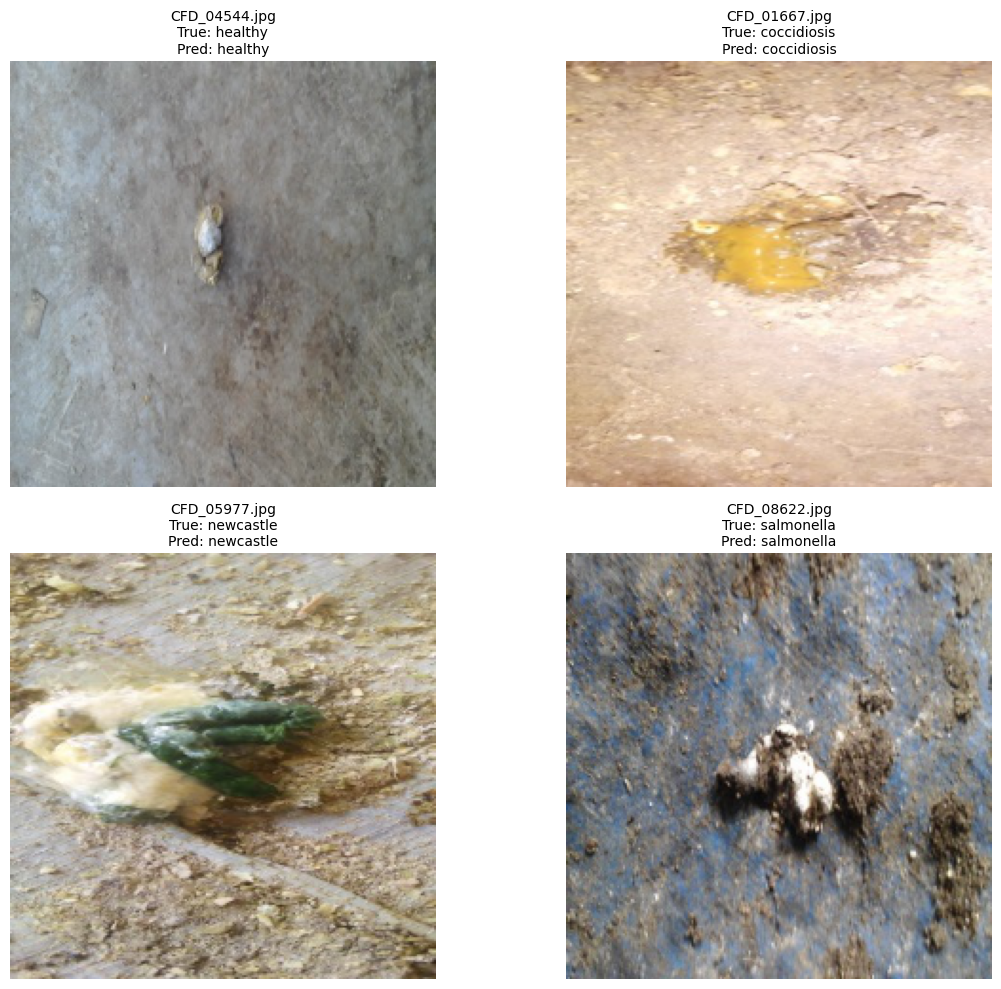

,filename,true_label,pred_label,stage1_pred
0,CFD_04544.jpg,healthy,healthy,healthy
1,CFD_01667.jpg,coccidiosis,coccidiosis,unhealthy
2,CFD_05977.jpg,newcastle,newcastle,unhealthy
3,CFD_08622.jpg,salmonella,salmonella,unhealthy


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1) CARGAR TEST Y ELEGIR UNA IMAGEN DE CADA CLASE
# =========================================================
MULTICLASS_TEST_CSV = ROOT / "03_final" / "splits" / "rebuild_v1" / "test.csv"
FINAL_IMAGES_DIR = ROOT / "03_final" / "images"

test_df = pd.read_csv(MULTICLASS_TEST_CSV).copy()

target_classes = ["healthy", "coccidiosis", "newcastle", "salmonella"]

samples = []
for cls in target_classes:
    row = test_df[test_df["label"] == cls].iloc[0]
    samples.append({
        "filename": row["filename"],
        "true_label": row["label"],
        "image_path": FINAL_IMAGES_DIR / row["filename"]
    })

# =========================================================
# 2) PREDECIR Y MOSTRAR
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

results_rows = []

for ax, sample in zip(axes, samples):
    image_path = sample["image_path"]
    true_label = sample["true_label"]

    pred = predict_final_feces_diagnosis(
        image_path=image_path,
        stage1_model=model,          # este es tu Stage 1 ya cargado
        stage2_model=stage2_model,   # este es tu Stage 2 ya cargado
        transform=transform
    )

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(
        f"{image_path.name}\n"
        f"True: {true_label}\n"
        f"Pred: {pred['final_pred']}",
        fontsize=10
    )

    results_rows.append({
        "filename": image_path.name,
        "true_label": true_label,
        "pred_label": pred["final_pred"],
        "stage1_pred": pred["stage1_pred"]
    })

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results_rows)
results_df